In [1]:
from pathlib import Path
import json
import os
import tempfile

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "ball_beam_matplotlib"),
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 140,
        "figure.figsize": (10.5, 6.6),
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "lines.linewidth": 1.7,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

In [2]:
LOG_ROOT = Path("../telemetry_logs")
if not LOG_ROOT.exists():
    LOG_ROOT = Path("telemetry_logs")

REQUIRED_COLUMNS = [
    "t_ms",
    "mode",
    "driver",
    "d_valid",
    "d_filt",
    "setp",
    "x",
    "theta_cmd",
    "theta_rel_meas",
]

POSITION_YLIM = (5.0, 14.0)
ANGLE_YLIM = (-4.2, 4.2)
DISTURBANCE_THRESHOLD_CM = 1.0
DISTURBANCE_IGNORE_S = 3.0
DISTURBANCE_SUSTAINED_SAMPLES = 3
DISPLAY_SMOOTH_WINDOW = 13
SETPOINT_CHANGE_EPS_CM = 0.05
EXPECTED_STAIRCASE_CM = np.array([12.50, 10.00, 7.50])

POSITION_COLOR = "#1f77b4"
SETPOINT_COLOR = "#222222"
COMMAND_COLOR = "#c23b22"
MEASURED_ANGLE_COLOR = "#2a7f62"

In [3]:
if "LOG_ROOT" not in globals():
    LOG_ROOT = Path("../telemetry_logs")
    if not LOG_ROOT.exists():
        LOG_ROOT = Path("telemetry_logs")

if "REQUIRED_COLUMNS" not in globals():
    REQUIRED_COLUMNS = [
        "t_ms",
        "mode",
        "driver",
        "d_valid",
        "d_filt",
        "setp",
        "x",
        "theta_cmd",
        "theta_rel_meas",
    ]


def has_required_columns(csv_path: Path) -> bool:
    if not csv_path.is_file() or csv_path.stat().st_size == 0:
        return False

    try:
        columns = pd.read_csv(csv_path, nrows=0).columns.str.strip()
    except Exception:
        return False

    return set(REQUIRED_COLUMNS).issubset(set(columns))


def latest_telemetry_csv(log_root: Path) -> Path:
    candidates = [
        csv_path
        for csv_path in log_root.glob("*/telemetry.csv")
        if has_required_columns(csv_path)
    ]
    if not candidates:
        raise FileNotFoundError(f"No valid telemetry.csv found under {log_root.resolve()}")

    return max(
        candidates,
        key=lambda path: (path.parent.stat().st_mtime, path.stat().st_mtime),
    )


csv_path = latest_telemetry_csv(LOG_ROOT)
run_dir = csv_path.parent
raw = pd.read_csv(csv_path)
raw.columns = raw.columns.str.strip()

print(f"Selected run: {run_dir}")
print(f"Telemetry CSV: {csv_path}")

meta_path = run_dir / "session_meta.json"
if meta_path.exists():
    metadata = json.loads(meta_path.read_text(encoding="utf-8"))
    print(f"Started at: {metadata.get('started_at', 'unknown')}")
    print(f"Port: {metadata.get('port', 'unknown')} @ {metadata.get('baud', 'unknown')}")

print(f"Rows loaded: {len(raw)}")

Selected run: ../telemetry_logs/20260424_164722
Telemetry CSV: ../telemetry_logs/20260424_164722/telemetry.csv
Started at: 2026-04-24T16:47:22
Port: /dev/cu.usbserial-A10N20X1 @ 115200
Rows loaded: 1309


In [4]:
def prepare_telemetry(frame: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    missing = [column for column in REQUIRED_COLUMNS if column not in frame.columns]
    if missing:
        raise ValueError(f"Missing required telemetry columns: {missing}")

    data = frame.copy()
    for column in REQUIRED_COLUMNS:
        data[column] = pd.to_numeric(data[column], errors="coerce")

    data = data.dropna(subset=["t_ms"]).sort_values("t_ms").reset_index(drop=True)
    if data.empty:
        raise ValueError("Telemetry CSV contains no usable timestamped rows")

    data["t_s"] = (data["t_ms"] - float(data["t_ms"].iloc[0])) / 1000.0
    data["valid_bool"] = data["d_valid"].fillna(0).astype(int).eq(1)
    data["closed_loop_bool"] = (
        data["mode"].fillna(-1).astype(int).eq(2)
        & data["driver"].fillna(0).astype(int).eq(1)
    )

    closed_loop = data.loc[data["closed_loop_bool"]].copy().reset_index(drop=True)
    if closed_loop.empty:
        raise ValueError("No closed-loop M2 rows found where mode == 2 and driver == 1")

    setpoint_change = closed_loop["setp"].diff().abs().fillna(0.0) > SETPOINT_CHANGE_EPS_CM
    closed_loop["segment_id"] = setpoint_change.cumsum().astype(int)
    return data, closed_loop


def valid_parts(frame: pd.DataFrame) -> list[pd.DataFrame]:
    valid = frame["valid_bool"].to_numpy(dtype=bool)
    parts = []
    start = None

    for index, is_valid in enumerate(valid):
        if is_valid and start is None:
            start = index
        elif not is_valid and start is not None:
            parts.append(frame.iloc[start:index])
            start = None

    if start is not None:
        parts.append(frame.iloc[start:])

    return [part for part in parts if not part.empty]


def plot_valid_line(ax, frame: pd.DataFrame, x_col: str, y_col: str, *, label: str, color: str, **kwargs) -> None:
    for part_index, part in enumerate(valid_parts(frame)):
        ax.plot(
            part[x_col],
            part[y_col],
            color=color,
            label=label if part_index == 0 else None,
            **kwargs,
        )


def display_position_trace(frame: pd.DataFrame) -> pd.Series:
    position = frame["d_filt"].where(frame["valid_bool"])
    return (
        position.rolling(DISPLAY_SMOOTH_WINDOW, center=True, min_periods=1)
        .median()
        .rolling(3, center=True, min_periods=1)
        .mean()
    )


def rounded_time_limit(seconds: float) -> float:
    if seconds <= 0.0:
        return 1.0
    return float(np.ceil(seconds / 5.0) * 5.0)


def draw_position_axis(ax, frame: pd.DataFrame, title: str) -> None:
    frame = frame.copy()
    frame["position_display"] = display_position_trace(frame)
    ax.step(
        frame["t_plot"],
        frame["setp"],
        where="post",
        color=SETPOINT_COLOR,
        linestyle="--",
        linewidth=1.6,
        label="setpoint",
    )
    plot_valid_line(
        ax,
        frame,
        "t_plot",
        "position_display",
        label="filtered ball position",
        color=POSITION_COLOR,
        linewidth=2.2,
    )
    ax.set_ylim(*POSITION_YLIM)
    ax.set_ylabel("position [cm]")
    ax.set_title(title)
    ax.legend(loc="best", frameon=True)


def draw_angle_axis(ax, frame: pd.DataFrame) -> None:
    ax.axhline(0.0, color="0.35", linewidth=0.9, alpha=0.75)
    plot_valid_line(
        ax,
        frame,
        "t_plot",
        "theta_cmd",
        label="commanded beam angle",
        color=COMMAND_COLOR,
    )
    plot_valid_line(
        ax,
        frame,
        "t_plot",
        "theta_rel_meas",
        label="measured beam angle",
        color=MEASURED_ANGLE_COLOR,
        alpha=0.9,
    )
    ax.set_ylim(*ANGLE_YLIM)
    ax.set_ylabel("beam angle [deg]")
    ax.set_xlabel("time [s]")
    ax.legend(loc="best", frameon=True)


def detect_disturbance(segment: pd.DataFrame) -> float | None:
    local_t = segment["t_plot"]
    mask = (
        segment["valid_bool"]
        & local_t.ge(DISTURBANCE_IGNORE_S)
        & segment["x"].abs().gt(DISTURBANCE_THRESHOLD_CM)
    ).to_numpy(dtype=bool)

    needed = max(1, int(DISTURBANCE_SUSTAINED_SAMPLES))
    for start in range(0, max(0, len(mask) - needed + 1)):
        if mask[start : start + needed].all():
            return float(local_t.iloc[start])

    return None


def segment_frame(closed_loop: pd.DataFrame, segment_id: int) -> pd.DataFrame:
    segment = closed_loop.loc[closed_loop["segment_id"].eq(segment_id)].copy()
    if segment.empty:
        raise ValueError(f"Missing closed-loop segment {segment_id}")
    segment["t_plot"] = segment["t_s"] - float(segment["t_s"].iloc[0])
    return segment


telemetry, closed_loop = prepare_telemetry(raw)
segment_summary = closed_loop.groupby("segment_id").agg(
    t_start_s=("t_s", "first"),
    t_end_s=("t_s", "last"),
    setpoint_cm=("setp", "first"),
    rows=("t_s", "size"),
)
print(f"Closed-loop rows: {len(closed_loop)}")
print(segment_summary.to_string(float_format=lambda value: f"{value:.3f}"))

Closed-loop rows: 1269
            t_start_s  t_end_s  setpoint_cm  rows
segment_id                                       
0               2.720   38.800       10.000   452
1              38.880   58.800       12.500   250
2              58.880   78.800       10.000   250
3              78.880  104.160        7.500   317


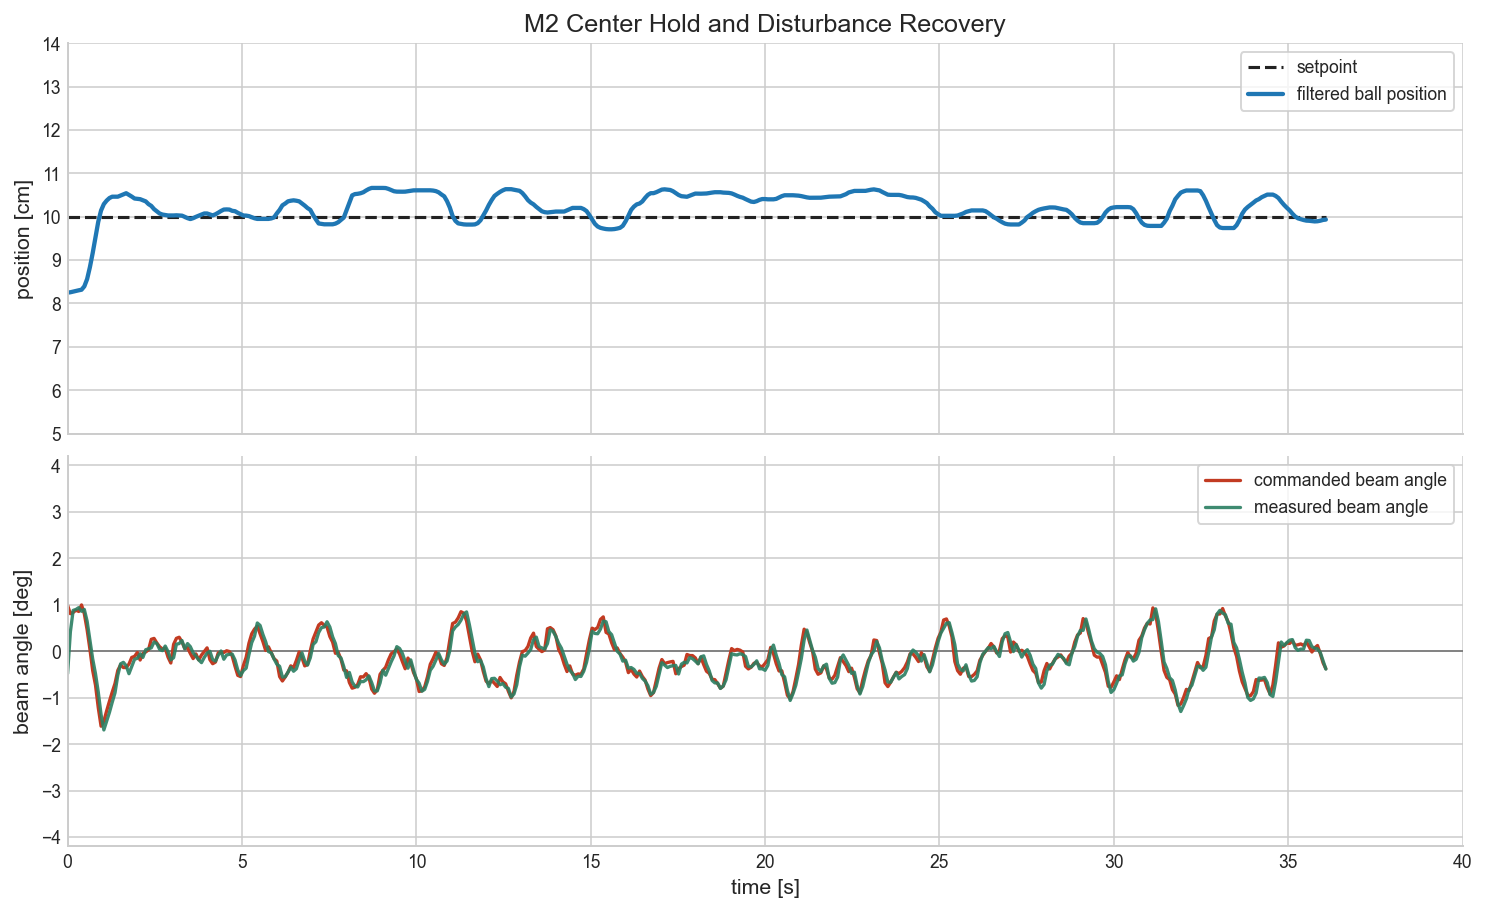

In [5]:
plt.close("all")

center = segment_frame(closed_loop, 0)
disturbance_s = detect_disturbance(center)

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10.5, 6.4), constrained_layout=True)
draw_position_axis(axes[0], center, "M2 Center Hold and Disturbance Recovery")
draw_angle_axis(axes[1], center)

if disturbance_s is not None:
    for axis in axes:
        axis.axvline(
            disturbance_s,
            color="0.25",
            linestyle=":",
            linewidth=1.2,
            label="detected disturbance",
        )
    for axis in axes:
        handles, labels = axis.get_legend_handles_labels()
        unique = dict(zip(labels, handles))
        axis.legend(unique.values(), unique.keys(), loc="best", frameon=True)

axes[1].set_xlim(0.0, rounded_time_limit(float(center["t_plot"].iloc[-1])))
plt.show()

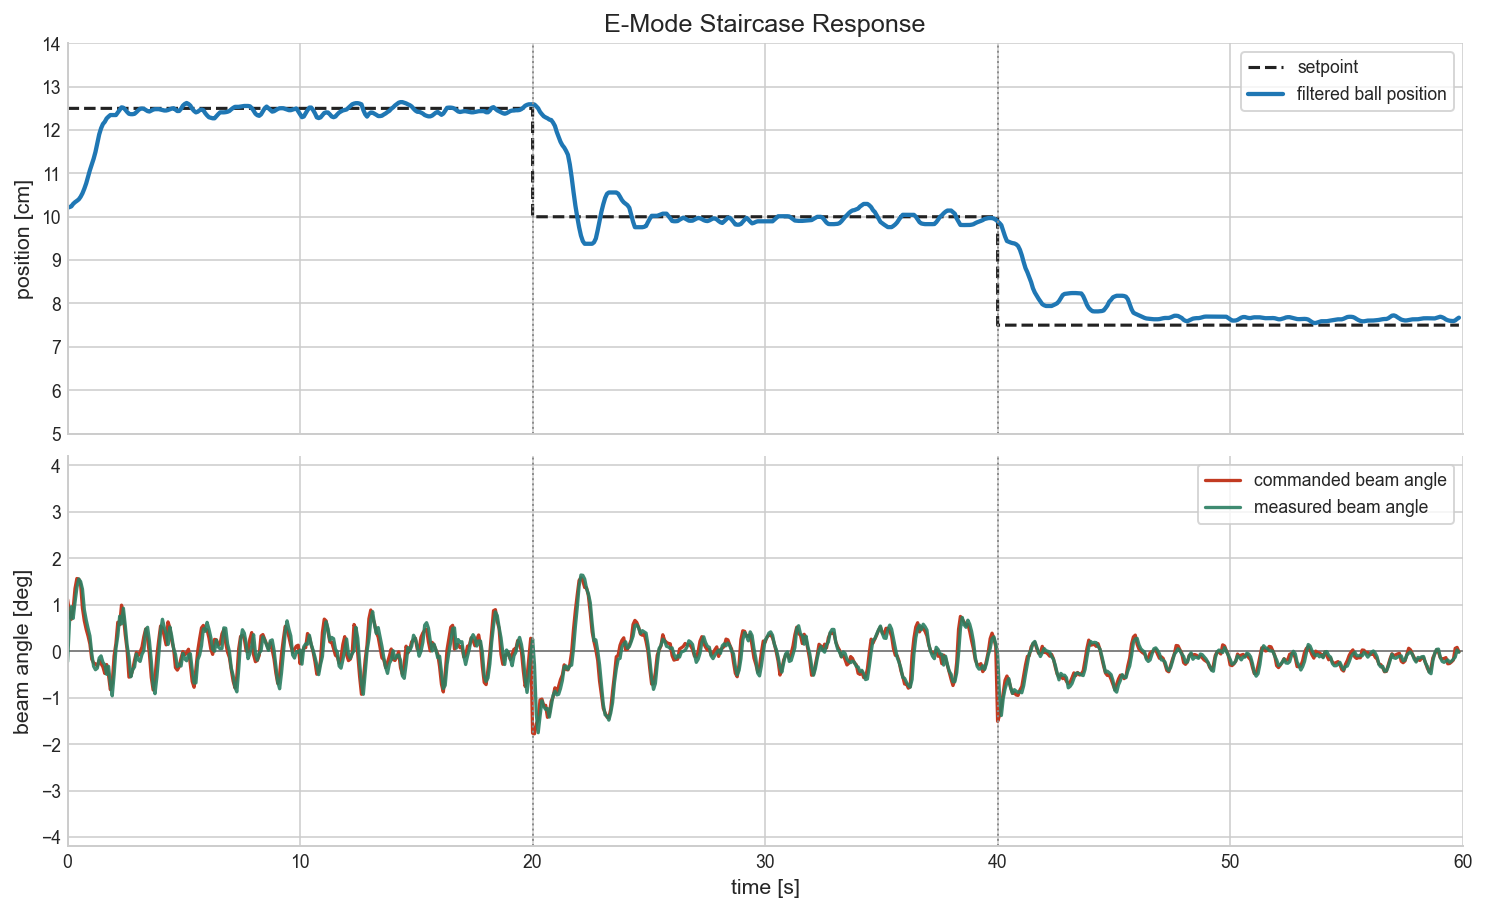

In [6]:
def find_staircase_segment_ids(closed_loop: pd.DataFrame) -> list[int]:
    segment_ids = sorted(closed_loop["segment_id"].unique().tolist())
    setpoints = {
        segment_id: float(closed_loop.loc[closed_loop["segment_id"].eq(segment_id), "setp"].iloc[0])
        for segment_id in segment_ids
    }

    for index in range(0, len(segment_ids) - len(EXPECTED_STAIRCASE_CM) + 1):
        candidate_ids = segment_ids[index : index + len(EXPECTED_STAIRCASE_CM)]
        candidate_setpoints = np.array([setpoints[segment_id] for segment_id in candidate_ids])
        if np.allclose(candidate_setpoints, EXPECTED_STAIRCASE_CM, atol=SETPOINT_CHANGE_EPS_CM):
            return candidate_ids

    if len(segment_ids) >= 4:
        return segment_ids[1:4]

    raise ValueError("Could not find the expected E-mode staircase segments")


staircase_ids = find_staircase_segment_ids(closed_loop)
staircase_segments = [closed_loop.loc[closed_loop["segment_id"].eq(segment_id)].copy() for segment_id in staircase_ids]
stage_durations = [float(segment["t_s"].iloc[-1] - segment["t_s"].iloc[0]) for segment in staircase_segments]
nominal_stage_duration_s = float(np.median(stage_durations[:2])) if len(stage_durations) >= 2 else stage_durations[-1]

trimmed_segments = []
for stage_index, segment in enumerate(staircase_segments):
    segment = segment.copy()
    segment["stage_index"] = stage_index
    segment["stage_t_s"] = segment["t_s"] - float(segment["t_s"].iloc[0])
    if stage_index == len(staircase_segments) - 1:
        segment = segment.loc[segment["stage_t_s"].le(nominal_stage_duration_s)].copy()
    trimmed_segments.append(segment)

staircase = pd.concat(trimmed_segments, ignore_index=True)
staircase_start_s = float(staircase["t_s"].iloc[0])
staircase["t_plot"] = staircase["t_s"] - staircase_start_s

fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10.5, 6.4), constrained_layout=True)
draw_position_axis(axes[0], staircase, "E-Mode Staircase Response")
draw_angle_axis(axes[1], staircase)

for stage_index in range(1, len(trimmed_segments)):
    boundary_s = float(trimmed_segments[stage_index]["t_s"].iloc[0]) - staircase_start_s
    for axis in axes:
        axis.axvline(boundary_s, color="0.55", linestyle=":", linewidth=1.0)

axes[1].set_xlim(0.0, rounded_time_limit(float(staircase["t_plot"].iloc[-1])))
plt.show()